# HVAC Electircity Demand Analysis and Prediction

## lag feature threshold

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor

np.random.seed(42)


In [13]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)

df_daily = pd.read_csv("./data/df_daily_feature_creation.csv")
df_daily["Time"] = pd.to_datetime(df_daily["Time"])
df_daily.set_index("Time", inplace=True)

In [14]:
lag_days = np.arange(1, 61, 1)

for lag in lag_days:
    df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
        "electricity_demand_values"
    ].shift(lag)
df_daily.dropna(inplace=True)



In [15]:
def train_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_pred - y_test))
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    df_results = pd.DataFrame(
        {"Time": y_test.index, "y_test": y_test, "y_pred": y_pred}
    )
    return df_results

In [16]:
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test

In [17]:
def plot_results(df_results, model_name):
    _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df_results["Time"], df_results["y_test"], label="Test")
    ax.plot(df_results["Time"], df_results["y_pred"], label="Predicted")
    ax.set_title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
def corr_features_plot(df_daily, threshold):
    correlations = df_daily.corr()["electricity_demand_values"]
    correlated_features = correlations[abs(correlations) > threshold].index
    _, ax = plt.subplots(figsize=(16, 16))
    sns.heatmap(
        df_daily.corr().loc[correlated_features, correlated_features], annot=True, ax=ax
    )
    ax.set_title(f"Correlation Matrix of Daily Data (abs(corr) >= {threshold})")
    plt.tight_layout()
    plt.show()

In [41]:
def correlation_threshold_train(df_daily, threshold, model_name, regressor, split=5):
    correlations = df_daily.corr()["electricity_demand_values"]
    correlated_features = correlations[abs(correlations) > threshold].index
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        df_daily[correlated_features].drop("electricity_demand_values", axis=1),
        df_daily[correlated_features]["electricity_demand_values"],
        test_size=0.2,
        random_state=42,
    )
    kf = KFold(n_splits=split, shuffle=True, random_state=42)
    mse_scores = -cross_val_score(
        regressor, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
    )
    mae_scores = -cross_val_score(
        regressor, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
    )
    r2_scores = cross_val_score(regressor, X_trainval, y_trainval, cv=kf, scoring="r2")
    # 计算RMSE、MAE和R-squared分数的均值
    rmse_scores = np.sqrt(mse_scores)
    mean_rmse = round(rmse_scores.mean(), 4)
    mean_mae = round(mae_scores.mean(), 4)
    mean_r2 = round(r2_scores.mean(), 4)
    res_dict = {
        "Model name": model_name,
        "corr_threshold": threshold,
        "Fold": split,
        "AVG RMSE": mean_rmse,
        "AVG MAE": mean_mae,
        "AVG R2": mean_r2,
    }
    return res_dict

In [42]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

In [43]:
correlation_threshold_train(df_daily, 0, "AdaBoost", ada_reg,5)

{'Model name': 'AdaBoost',
 'corr_threshold': 0,
 'Fold': 5,
 'AVG RMSE': 395.9587,
 'AVG MAE': 232.3656,
 'AVG R2': 0.9846}

In [51]:
thresholds = [0, 0.1, 0.3, 0.5, 0.7, 0.8]

results_ls = [
    correlation_threshold_train(df_daily, threshold, "AdaBoost", ada_reg, 5)
    for threshold in thresholds
]

df_results = pd.DataFrame(results_ls)

In [52]:
df_results

,Model name,corr_threshold,Fold,AVG RMSE,AVG MAE,AVG R2
0,AdaBoost,0.0,5,395.9587,232.3656,0.9846
1,AdaBoost,0.1,5,390.9794,225.5831,0.9849
2,AdaBoost,0.3,5,384.1279,229.6142,0.9852
3,AdaBoost,0.5,5,472.4404,296.9711,0.9781
4,AdaBoost,0.7,5,2230.8556,1367.6942,0.5194
5,AdaBoost,0.8,5,2230.8556,1367.6942,0.5194


In [54]:
correlation_threshold_train(df_daily, 0.35, "AdaBoost", ada_reg, 5)

{'Model name': 'AdaBoost',
 'corr_threshold': 0.35,
 'Fold': 5,
 'AVG RMSE': 406.0832,
 'AVG MAE': 244.216,
 'AVG R2': 0.9836}

In [55]:
thresholds = [0.2, 0.25,0.3, 0.4,0.45,0.5]

results_ls = [
    correlation_threshold_train(df_daily, threshold, "AdaBoost", ada_reg, 5)
    for threshold in thresholds
]

df_results = pd.DataFrame(results_ls)

In [56]:
df_results

,Model name,corr_threshold,Fold,AVG RMSE,AVG MAE,AVG R2
0,AdaBoost,0.20,5,352.2266,219.1364,0.9877
1,AdaBoost,0.25,5,380.9452,223.7269,0.9859
2,AdaBoost,0.30,5,384.1279,229.6142,0.9852
3,AdaBoost,0.40,5,442.9898,268.9441,0.9807
4,AdaBoost,0.45,5,468.1384,286.6456,0.9785
5,AdaBoost,0.50,5,472.4404,296.9711,0.9781


In [57]:
thresholds = [0.55,0.6,0.65,0.7]

results_ls = [
    correlation_threshold_train(df_daily, threshold, "AdaBoost", ada_reg, 5)
    for threshold in thresholds
]

df_results = pd.DataFrame(results_ls)

In [58]:
df_results

,Model name,corr_threshold,Fold,AVG RMSE,AVG MAE,AVG R2
0,AdaBoost,0.55,5,497.9570,306.2525,0.9757
1,AdaBoost,0.60,5,767.7130,470.7523,0.9425
2,AdaBoost,0.65,5,1351.7015,789.8676,0.8242
3,AdaBoost,0.70,5,2230.8556,1367.6942,0.5194


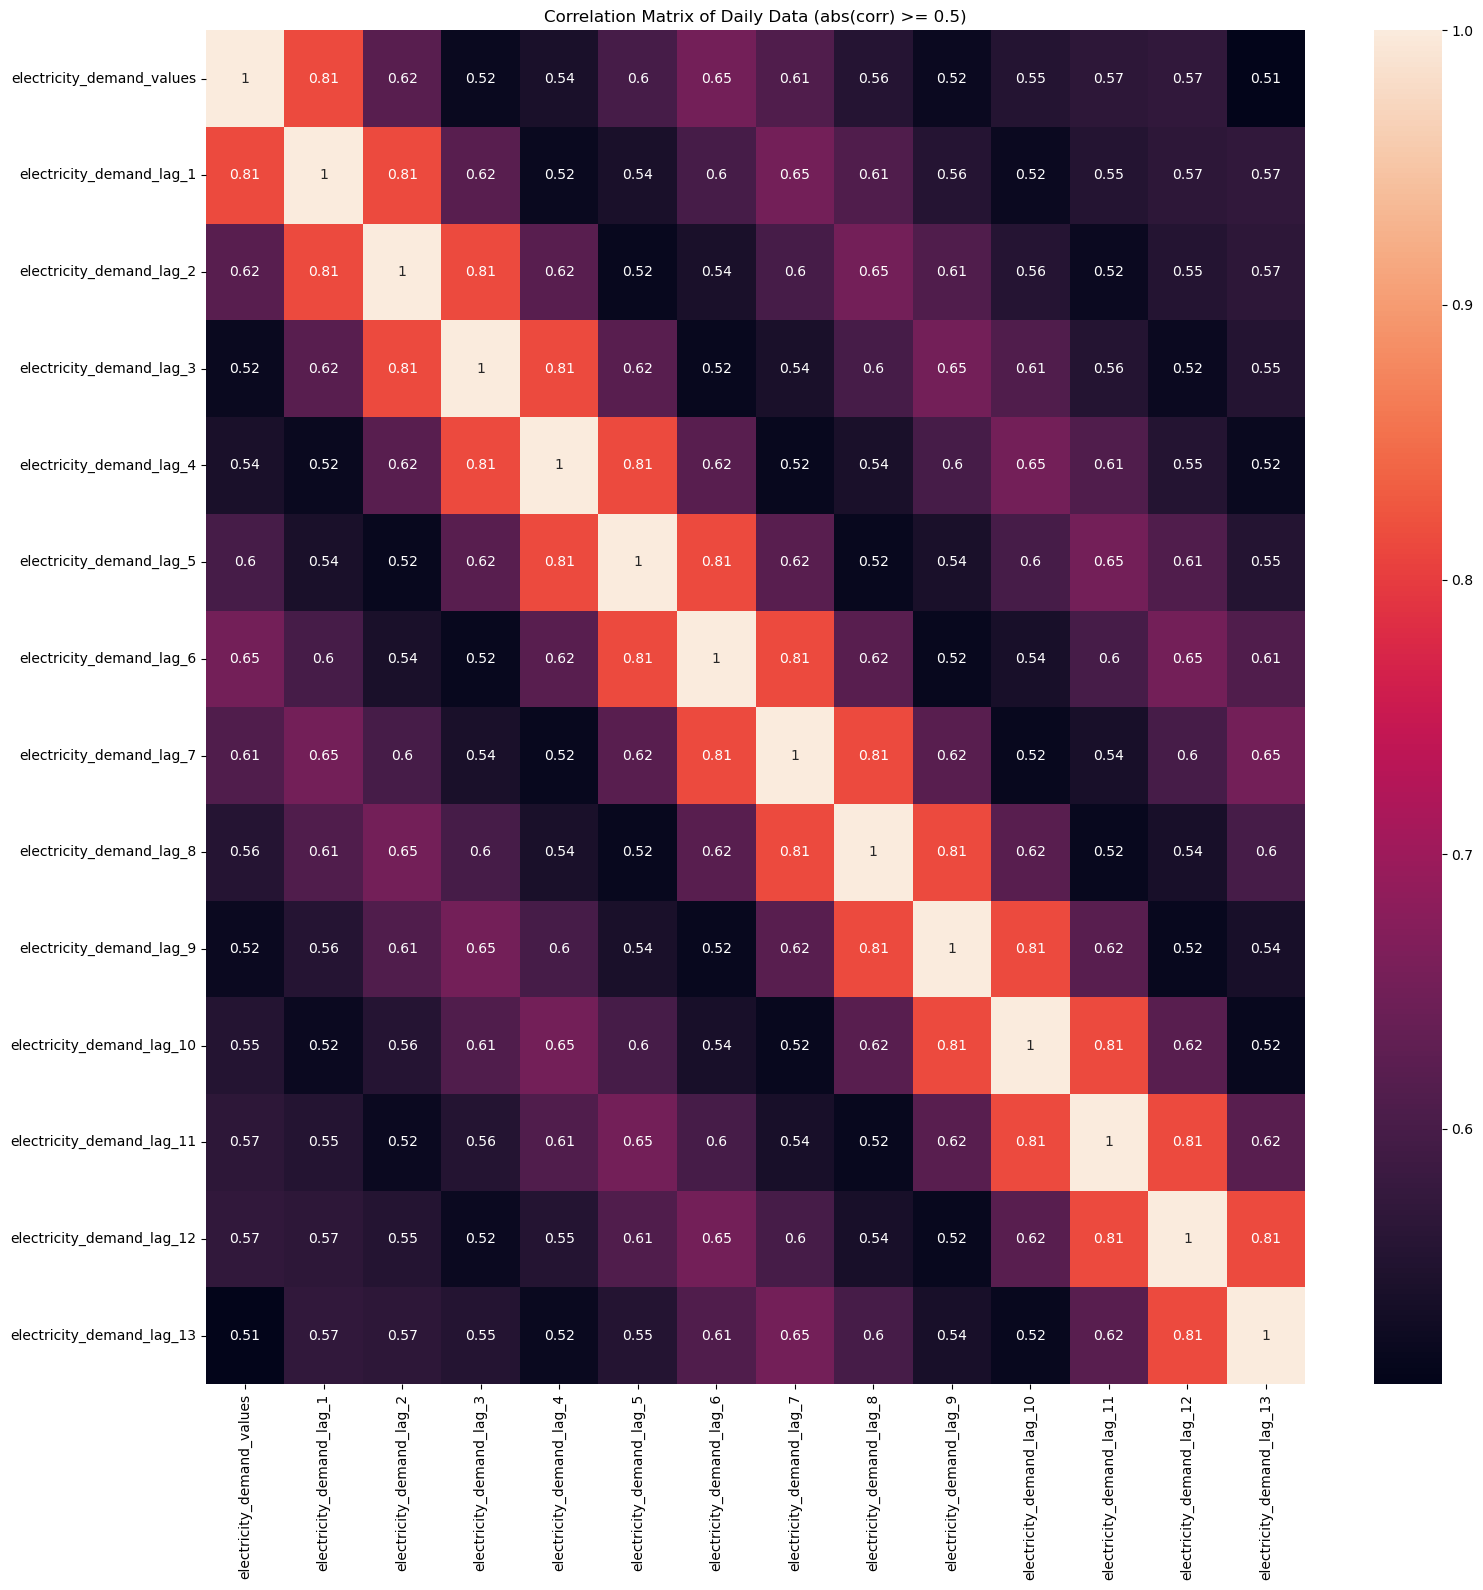

In [63]:
corr_features_plot(df_daily, 0.5)

# Back up 

In [ ]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.3].index

In [ ]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily[correlated_features], "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 30), (516,), (172, 30), (172,))

In [ ]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 1727.4204
MAE: 790.6391
R2: 0.7800


In [ ]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 1228.9242
MAE: 825.6042
R2: 0.8886


In [ ]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 652.5463
MAE: 349.2692
R2: 0.9686


### Compare with adding rolling mean and standard deviation features

- Remove the lag features for electricity demand, add more rolling mean and standard deviation features

In [ ]:
df_daily = pd.read_csv("./data/df_daily_feature_creation.csv")
df_daily["Time"] = pd.to_datetime(df_daily["Time"])
df_daily.set_index("Time", inplace=True)
df_daily = df_daily[["electricity_demand_values"]]

In [ ]:
window_sizes = np.arange(2, 61, 1)

for window_size in window_sizes:
    df_daily[f"electricity_demand_{window_size}d_mean"] = (
        df["electricity_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"electricity_demand_{window_size}d_std"] = (
        df["electricity_demand_values"].rolling(window=window_size).std()
    )
    
    df_daily[f"heat_demand_{window_size}d_mean"] = (
            df["heat_demand_values"].rolling(window=window_size).mean()
        )
    df_daily[f"heat_demand_{window_size}d_std"] = (
            df["heat_demand_values"].rolling(window=window_size).std()
        )


df_daily.dropna(inplace=True)

/var/folders/bz/8yf5rf0s1yzd3gl6nw6xvclw0000gn/T/ipykernel_8098/3469378284.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily[f"heat_demand_{window_size}d_std"] = (
/var/folders/bz/8yf5rf0s1yzd3gl6nw6xvclw0000gn/T/ipykernel_8098/3469378284.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily[f"electricity_demand_{window_size}d_mean"] = (
/var/folders/bz/8yf5rf0s1yzd3gl6nw6xvclw0000gn/T/ipykernel_8098/3469378284.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

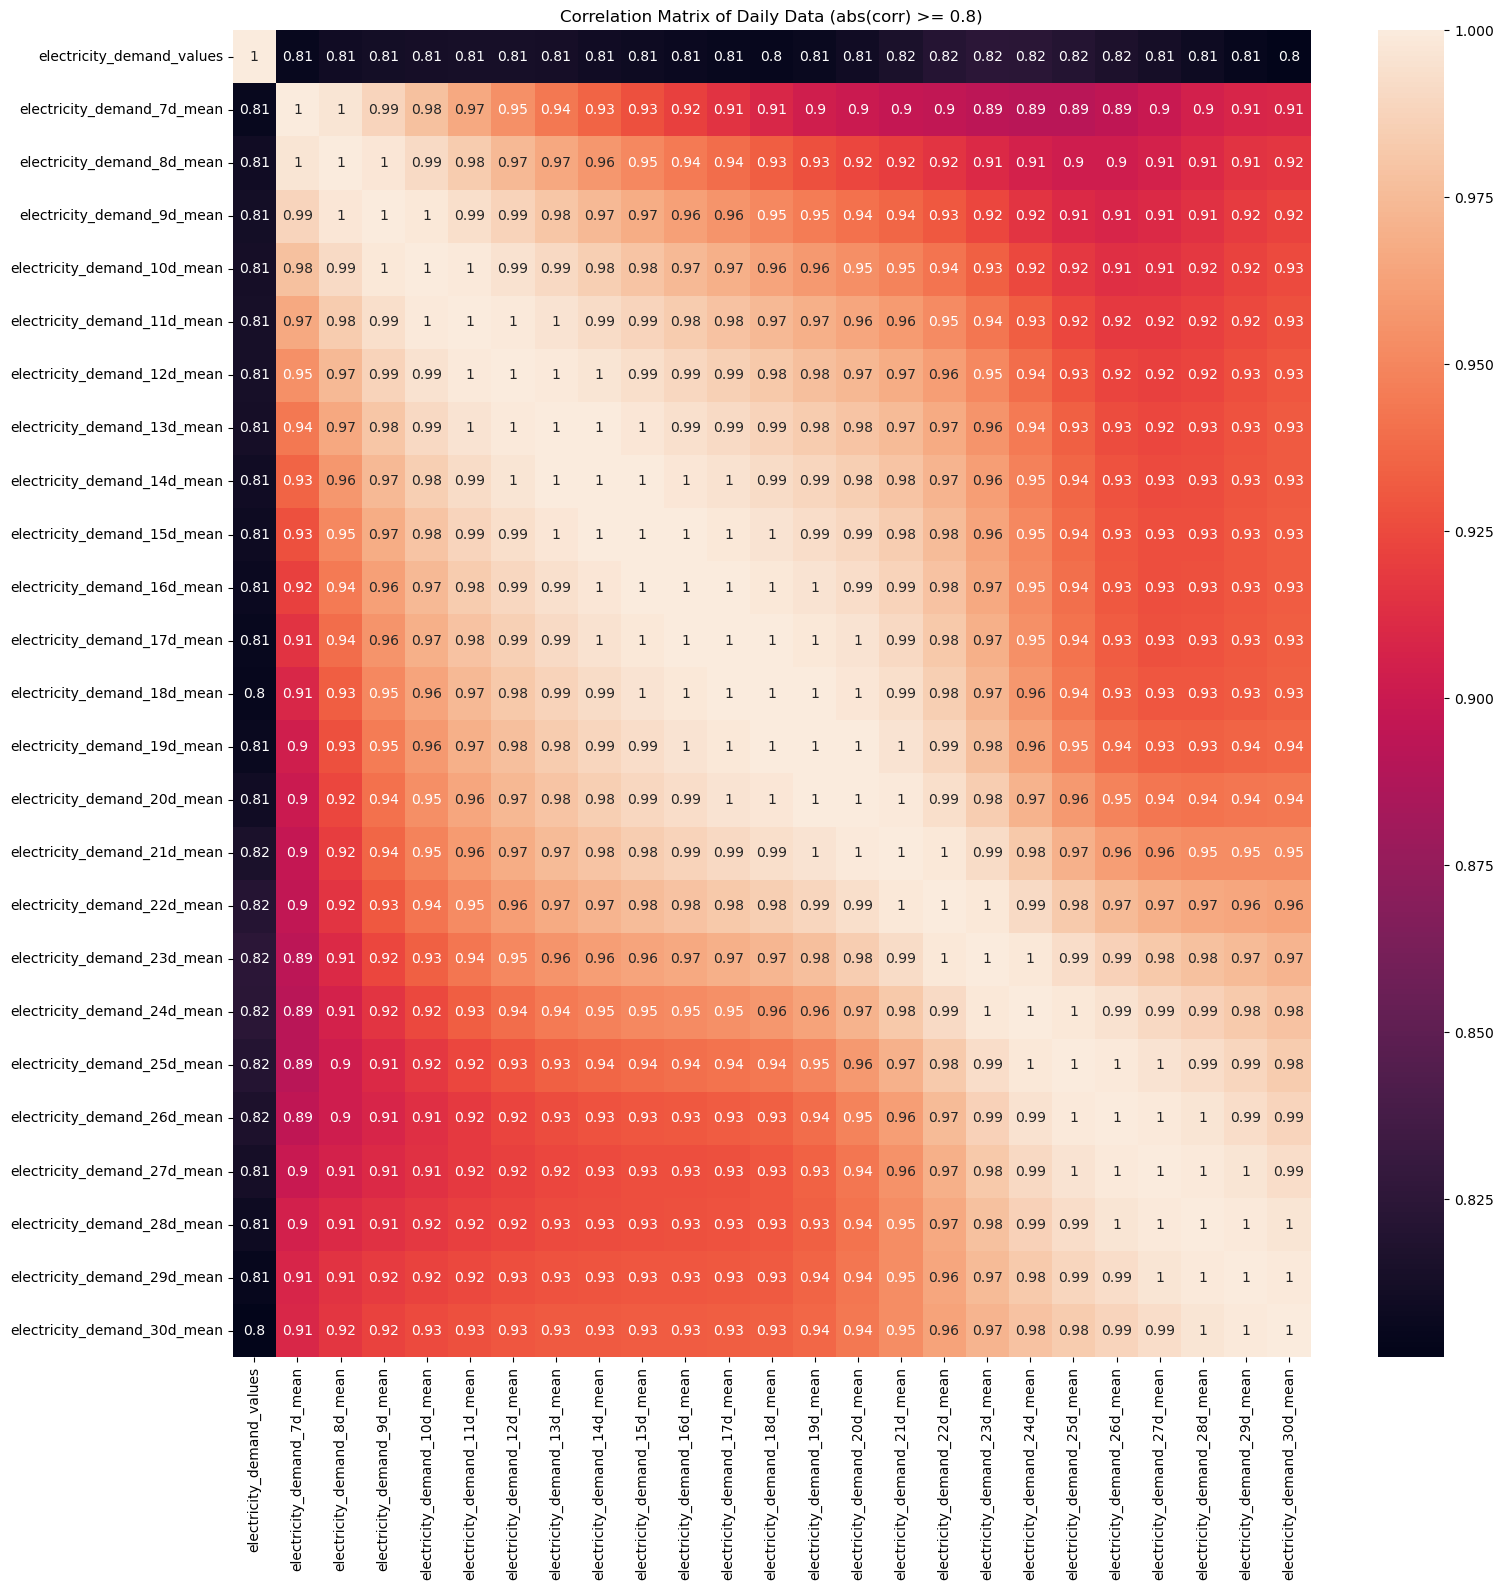

In [ ]:
corr_features_plot(df_daily, 0.8)

In [ ]:
correlations = df_daily.corr()["electricity_demand_values"].sort_values(ascending=False)

In [ ]:
correlated_features = correlations[abs(correlations) > 0.3].index
low_corr_feature = correlations[abs(correlations) <= 0.3].index
low_corr_feature_ls = df_daily.corr()["electricity_demand_values"][low_corr_feature]

In [ ]:
for feature, value in low_corr_feature_ls.items():
    print(f"Lower correlation features(<=0.3):\n{feature}: {value:.4f}")

Lower correlation features(<=0.3):
heat_demand_7d_mean: 0.1343
Lower correlation features(<=0.3):
heat_demand_8d_mean: 0.1337
Lower correlation features(<=0.3):
heat_demand_6d_mean: 0.1333
Lower correlation features(<=0.3):
heat_demand_9d_mean: 0.1312
Lower correlation features(<=0.3):
heat_demand_5d_mean: 0.1308
Lower correlation features(<=0.3):
heat_demand_10d_mean: 0.1273
Lower correlation features(<=0.3):
heat_demand_4d_mean: 0.1269
Lower correlation features(<=0.3):
heat_demand_11d_mean: 0.1219
Lower correlation features(<=0.3):
heat_demand_3d_mean: 0.1218
Lower correlation features(<=0.3):
heat_demand_2d_mean: 0.1156
Lower correlation features(<=0.3):
heat_demand_12d_mean: 0.1154
Lower correlation features(<=0.3):
heat_demand_13d_mean: 0.1082
Lower correlation features(<=0.3):
heat_demand_14d_mean: 0.1008
Lower correlation features(<=0.3):
heat_demand_15d_mean: 0.0935
Lower correlation features(<=0.3):
heat_demand_16d_mean: 0.0866
Lower correlation features(<=0.3):
heat_demand_1

In [ ]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily[correlated_features], "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 118), (516,), (172, 118), (172,))

In [ ]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 2489.1784
MAE: 1512.5386
R2: 0.5431


In [ ]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 1503.2473
MAE: 992.2517
R2: 0.8334


In [ ]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 1464.6077
MAE: 931.2875
R2: 0.8418


- Performance is worse than the model with lag features for electricity demand.

## Cross validation (Kfold CV)

### lag features for electricity demand

Given the best performance of electricity demand lag features, we will use this dataset for cross validation.

In [ ]:
df_daily = pd.read_csv("./data/df_daily_feature_creation.csv")
df_daily["Time"] = pd.to_datetime(df_daily["Time"])
df_daily.set_index("Time", inplace=True)
df_daily = df_daily[["electricity_demand_values"]]

In [ ]:
lag_days = np.arange(1, 61, 1)

for lag in lag_days:
    df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
        "electricity_demand_values"
    ].shift(lag)

In [ ]:
df_daily.dropna(inplace=True)

In [ ]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.3].index

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_daily[correlated_features].drop("electricity_demand_values", axis=1),
    df_daily[correlated_features]["electricity_demand_values"],
    test_size=0.2,
    random_state=42,
)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []

for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mae_ls.append(mae)
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R^2 Score: {r2}")

RMSE: 387.0060089376672
MAE: 238.34609861804276
R^2 Score: 0.9848658675283046
RMSE: 438.68604096883115
MAE: 232.95930879269991
R^2 Score: 0.9808704952982699
RMSE: 519.2410197983097
MAE: 274.1702082649
R^2 Score: 0.9761693423131104
RMSE: 316.30247534977104
MAE: 229.82416412827567
R^2 Score: 0.9909378285092921
RMSE: 307.0135623189466
MAE: 212.58787957110755
R^2 Score: 0.9902827961560203


In [ ]:
# Use KFold + cross_val_score to calculate RMSE, MAE, and R-squared scores
mse_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
)
mae_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
)
r2_scores = cross_val_score(ada_reg, X_trainval, y_trainval, cv=kf, scoring="r2")

# Calculate the RMSE, MAE, and R-squared scores' mean
rmse_scores = np.sqrt(mse_scores)
mean_rmse = rmse_scores.mean()
mean_mae = mae_scores.mean()
mean_r2 = r2_scores.mean()

In [ ]:
# Print the results
print("Mean RMSE:", round(mean_rmse, 4))
print("Mean MAE:", round(mean_mae, 4))
print("Mean R-squared score:", round(mean_r2, 4))

Mean RMSE: 393.6498
Mean MAE: 237.5775
Mean R-squared score: 0.9846
